In [99]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import pennylane as qml

# Suppress deprecation warnings
from tensorflow.python.util import deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False
print("Using TensorFlow backend:", tf.__version__)

Using TensorFlow backend: 2.18.0


In [100]:
# Step 2: Define parameters for the Monte Carlo simulation
S0 = 100  # Initial stock price
mu = 0.1  # Expected return
sigma = 0.2  # Volatility
T = 1.0  # Time period (1 year)
N = 252  # Number of time steps (trading days in a year)
dt = T / N  # Time step

In [101]:
# Step 3: Define the quantum device with 2 qubits and 1000 shots (samples)
dev = qml.device("default.qubit", wires=2, shots=1000)

In [102]:
# Step 4: Define the quantum circuit
@qml.qnode(dev)
def circuit(params):
    qml.RX(params[0], wires=0)  # Encode data using RX rotation
    qml.RY(params[1], wires=1)  # Encode data using RY rotation
    qml.CNOT(wires=[0, 1])      # Introduce entanglement
    return qml.sample(qml.PauliZ(0)), qml.sample(qml.PauliZ(1))

# Function to encode LSTM predictions into quantum circuit
def encode_data_to_quantum(predictions):
    encoded_results = []
    for pred in predictions:
        # Normalize prediction to fit into the range [0, 2*pi] for RX/RY gates
        normalized_pred = 2 * np.pi * (pred / np.max(predictions))
        params = [normalized_pred[0], normalized_pred[0]]  # Using same value for both qubits
        samples_0, samples_1 = circuit(params)
        encoded_results.append(np.mean(samples_0 + samples_1))  # Aggregate result as a feature
    return np.array(encoded_results)

In [103]:
# Step 5: Load and preprocess training data
dataset_train = pd.read_csv('NVDA - Training.csv')
training_set = dataset_train.iloc[:, 1:2].values

# Feature Scaling
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

# Creating data structure with 60 timesteps and 1 output
X_train, y_train = [], []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [104]:
# Step 6: Build the LSTM model
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

# Step 7: Compile and train the RNN
regressor.compile(optimizer='adam', loss='mean_squared_error')
regressor.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100


/Users/alexanderdagher/Documents/new project/myenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0499
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0033
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0031
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0026
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0028
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0027
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0022
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0022
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0022
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0026
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0023
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0023
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0021
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0023
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0019
E

In [105]:
# Step 8: Load and preprocess test data
dataset_test = pd.read_csv('NVDA - Test.csv')
DATE = dataset_test.iloc[:, 0:1].values
real_stock_price = dataset_test.iloc[:, 1:2].values

# Prepare test data for prediction
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

X_test = []
for i in range(60, 80):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


In [106]:
# Step 9: Perform Monte Carlo simulation for adjustments
adjusted_predictions = []
encoded_features = encode_data_to_quantum(predicted_stock_price)  # Encode LSTM predictions into quantum circuit
for idx, lstm_price in enumerate(predicted_stock_price):
    monte_carlo_paths = []
    for _ in range(1000):  # 100 Monte Carlo simulations per prediction
        prices = [lstm_price[0]]
        for _ in range(N):
            Z = np.random.normal(0, 1)
            S_t = prices[-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
            prices.append(S_t)
        monte_carlo_paths.append(prices[-1])

    mean_monte_carlo = np.mean(monte_carlo_paths)
    # Normalize Monte Carlo mean and quantum feature
    monte_carlo_norm = (mean_monte_carlo - np.min(monte_carlo_paths)) / (np.max(monte_carlo_paths) - np.min(monte_carlo_paths))
    quantum_norm = encoded_features[idx]  # Quantum output normalized between 0 and 1

    # Combine LSTM, Monte Carlo, and Quantum adjustments
    adjusted_price = 0.6 * lstm_price[0] + 0.2 * monte_carlo_norm * lstm_price[0] + 0.2 * quantum_norm * lstm_price[0]
    adjusted_predictions.append(adjusted_price)

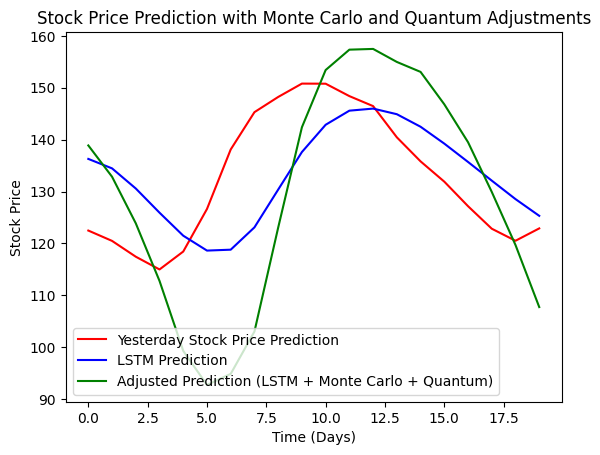

In [97]:
# Step 10: Visualize the results
plt.plot(real_stock_price, color='red', label='Yesterday Stock Price Prediction')
plt.plot(predicted_stock_price, color='blue', label='LSTM Prediction')
plt.plot(adjusted_predictions, color='green', label='Adjusted Prediction (LSTM + Monte Carlo + Quantum)')
plt.title('Stock Price Prediction with Monte Carlo and Quantum Adjustments')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [98]:
# Step 11: Save results
adjusted_predictions = np.array(adjusted_predictions).reshape(-1, 1)
output_test = np.column_stack((DATE, real_stock_price, predicted_stock_price, adjusted_predictions))
np.savetxt("Adjusted Predictions Output.csv", output_test, delimiter=',', fmt='%s',
           header="DATE, Yesterday Prediction, LSTM Predicted Price, Adjusted Price")